In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

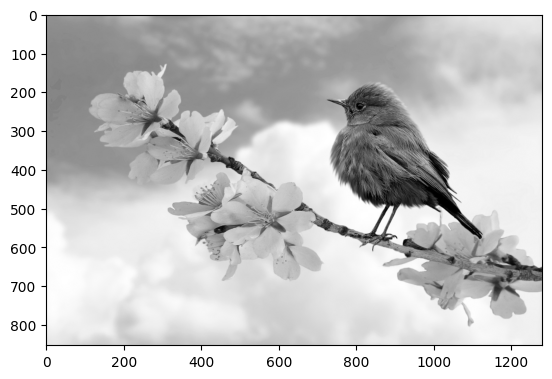

In [4]:
plt.imshow(image, cmap="gray")

In [5]:
def add_salt_pepper_noise(image, probability = 0.3):
  noisy = image.copy()

  random = np.random.rand(*image.shape)

  noisy[random < probability / 2] = 0
  noisy[random > 1 - probability / 2] = 255

  return noisy

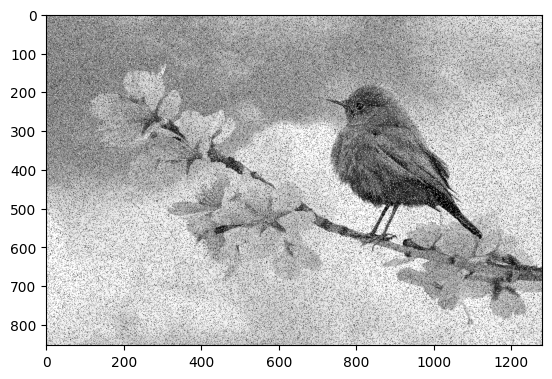

In [6]:
prob  = 0.2

noisy = add_salt_pepper_noise(image, prob)

plt.imshow(noisy, cmap = "gray")

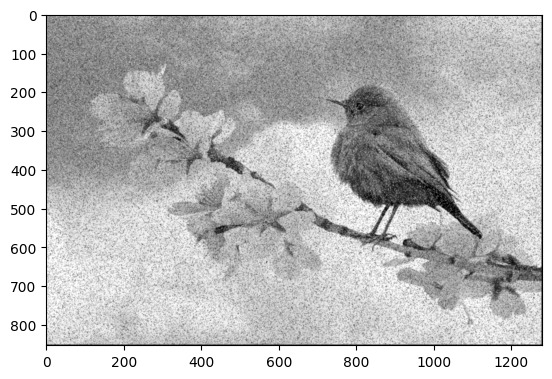

In [9]:
height, width = noisy.shape
filtered_image = np.zeros((height, width), dtype=np.uint8)

for r in range(1, height - 1):
    for c in range(1, width - 1):
        grid_sum = 0
        for i in range(-1, 2):
            for j in range(-1, 2):
                grid_sum += int(noisy[r + i, c + j])

        mean_val = grid_sum / 9
        filtered_image[r, c] = mean_val

plt.imshow(filtered_image, cmap="gray")